In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", version=1)

In [2]:
print(f"Shape of dataset : ",boston.data.shape)

Shape of dataset :  (506, 13)


In [3]:
print(boston.feature_names)

['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


CRIM : Per capita crime rate by town
ZN : Proportion of residential land zoned for lots over 25000 sq.ft.
INDUX : proportion of non-retail business acres per town
CHAS : Charles RIver dummy variable (=1 if tract bounds river, 0 otherwise)
NOX : nitric oxides concentration (parts pr 10 million)
RM : average number of romms per dwelling
AGE : Propotion of owner occupied units built prior to 1940
DIS : Weighted distances to five boston employment centres
RAD : Index of accessibility to radial highways
TAX : Full-value property-ax rate per $10000
PTRATIO : pupil-teacher ratio by town
B : 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
LSTAT : % lower status of the population
MEDV : Median value of owner-occupied home in $1000's

In [4]:
df = pd.DataFrame(boston.data)
df.columns = boston.feature_names

In [5]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33


In [8]:
print(f"the target: {boston.target_names}")
print(f"Shape of target : {boston.target.shape}")

the target: ['MEDV']
Shape of target : (506,)


In [9]:
df["MEDV"] = boston.target

In [25]:
df.sample(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
64,0.01951,17.5,1.38,0,0.4161,7.104,59.5,9.2229,3,216.0,18.6,393.24,8.05,33.0
284,0.00906,90.0,2.97,0,0.4000,7.088,20.8,7.3073,1,285.0,15.3,394.72,7.85,32.2
121,0.07165,0.0,25.65,0,0.5810,6.004,84.1,2.1974,2,188.0,19.1,377.67,14.27,20.3
132,0.59005,0.0,21.89,0,0.6240,6.372,97.9,2.3274,4,437.0,21.2,385.76,11.12,23.0
172,0.13914,0.0,4.05,0,0.5100,5.572,88.5,2.5961,5,296.0,16.6,396.90,14.69,23.1


## EDA (Exploratory Data Analysis)

In [ ]:
df.info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


In [12]:
df.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


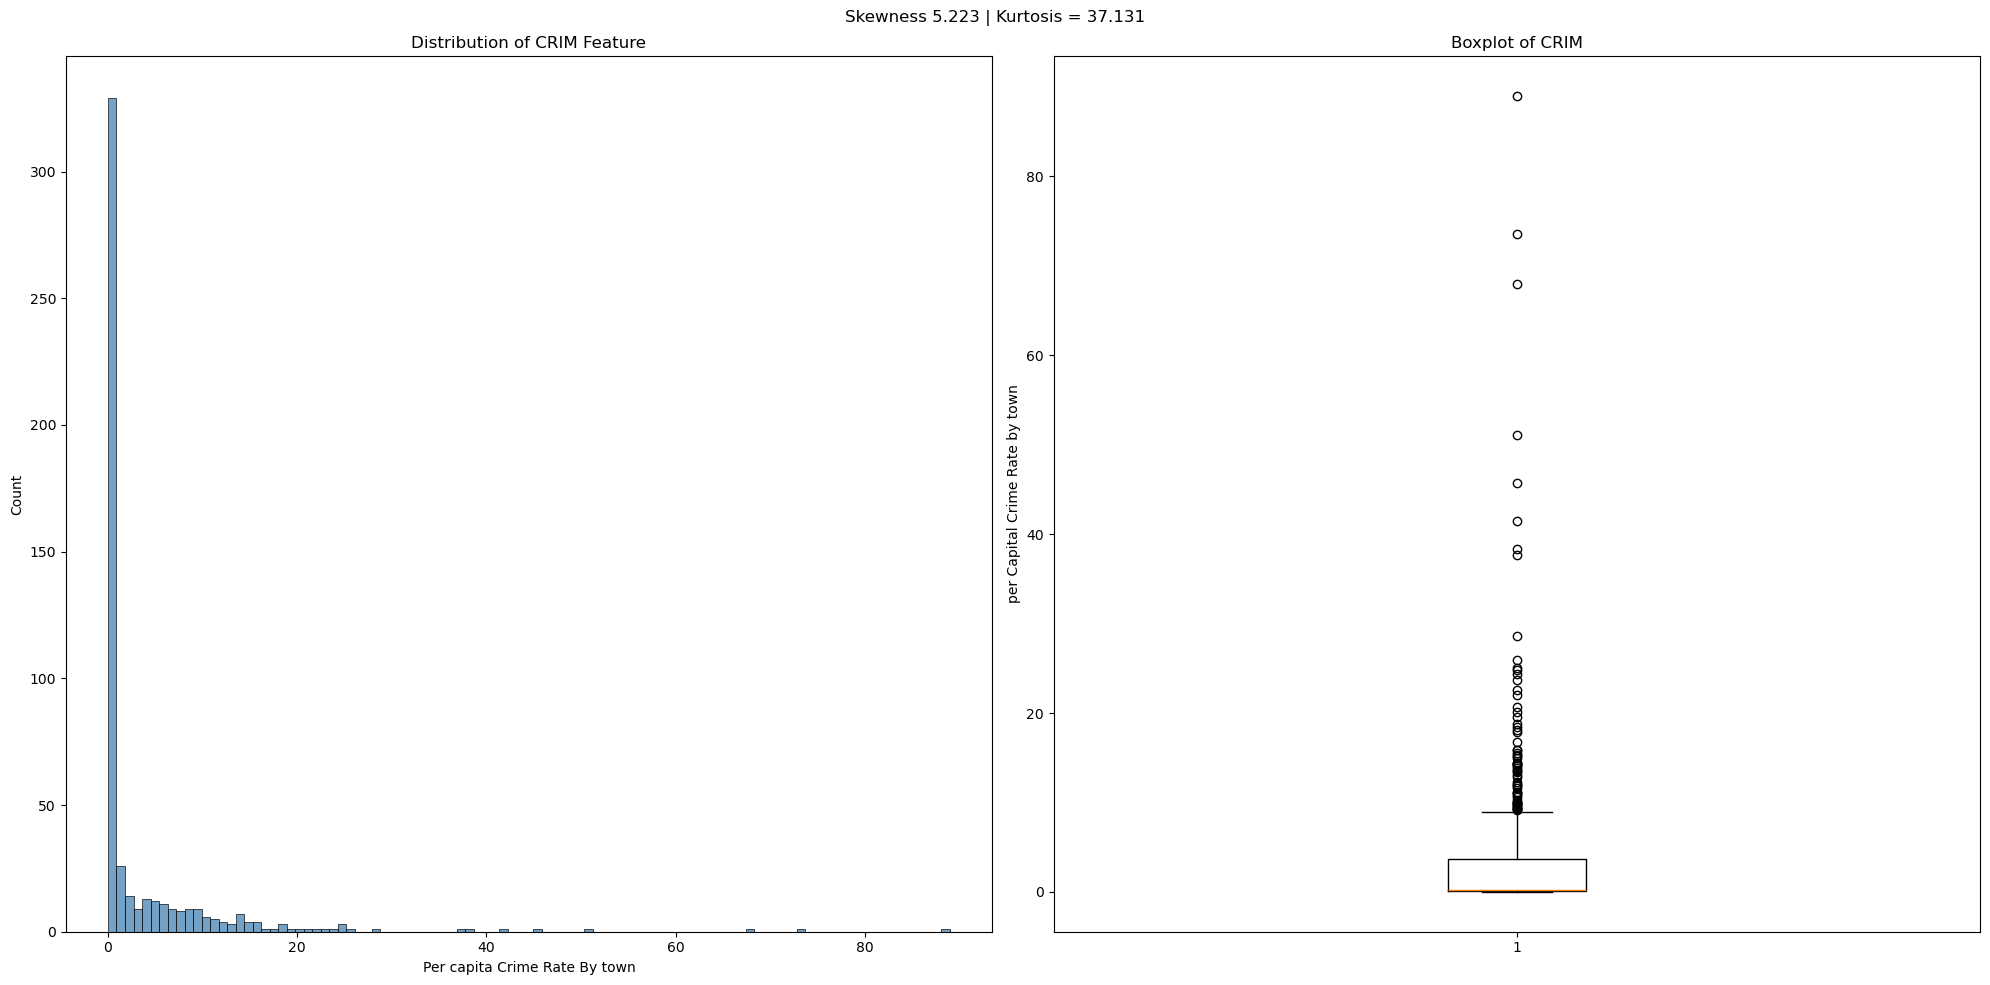

In [28]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.histplot(x=df["CRIM"], color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of CRIM Feature")
axes[0].set_xlabel("Per capita Crime Rate By town")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["CRIM"], vert=True)
axes[1].set_title("Boxplot of CRIM")
axes[1].set_ylabel("per Capital Crime Rate by town")

plt.suptitle(f"Skewness {df['CRIM'].skew():.3f} | Kurtosis = {df['CRIM'].kurtosis():.3f}")
plt.tight_layout()
plt.show()

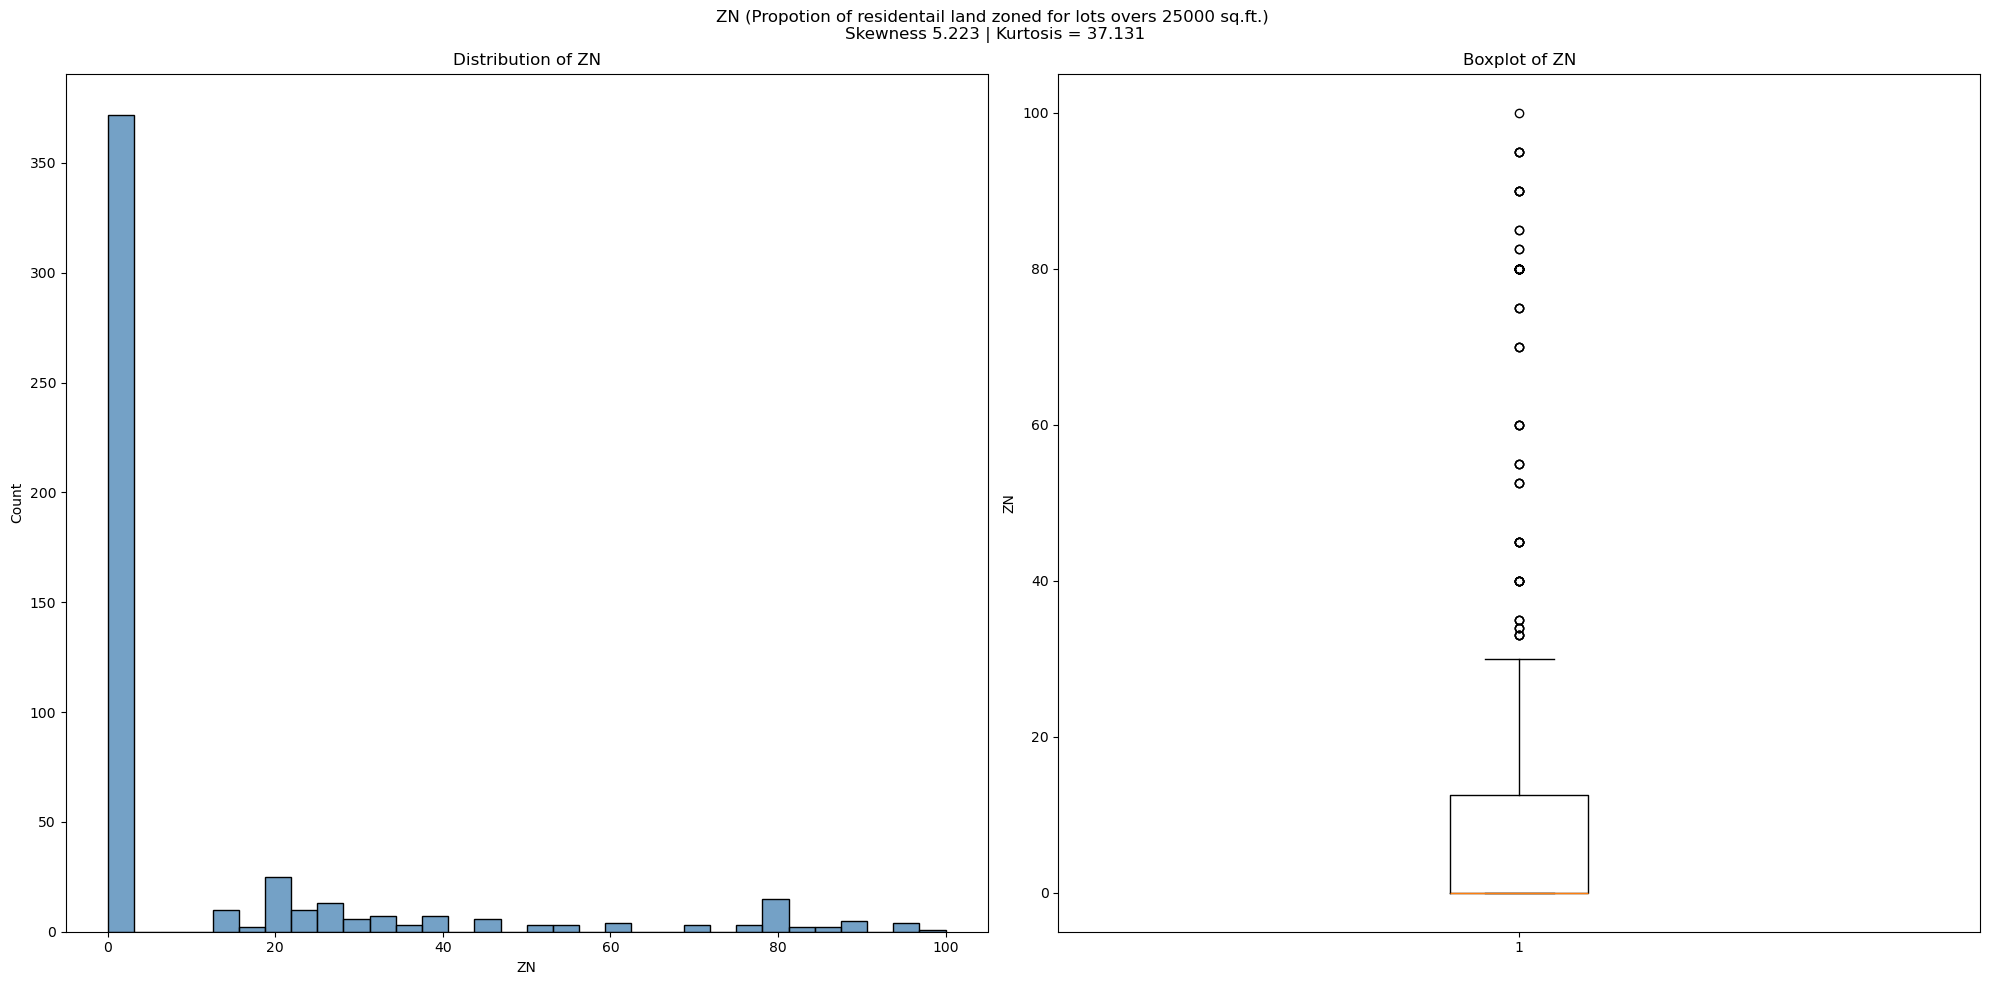

In [29]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.histplot(x=df["ZN"], color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of ZN")
axes[0].set_xlabel("ZN")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["ZN"], vert=True)
axes[1].set_title("Boxplot of ZN")
axes[1].set_ylabel("ZN")

plt.suptitle(f"ZN (Propotion of residentail land zoned for lots overs 25000 sq.ft.) \nSkewness {df['CRIM'].skew():.3f} | Kurtosis = {df['CRIM'].kurtosis():.3f}")
plt.tight_layout()
plt.show()

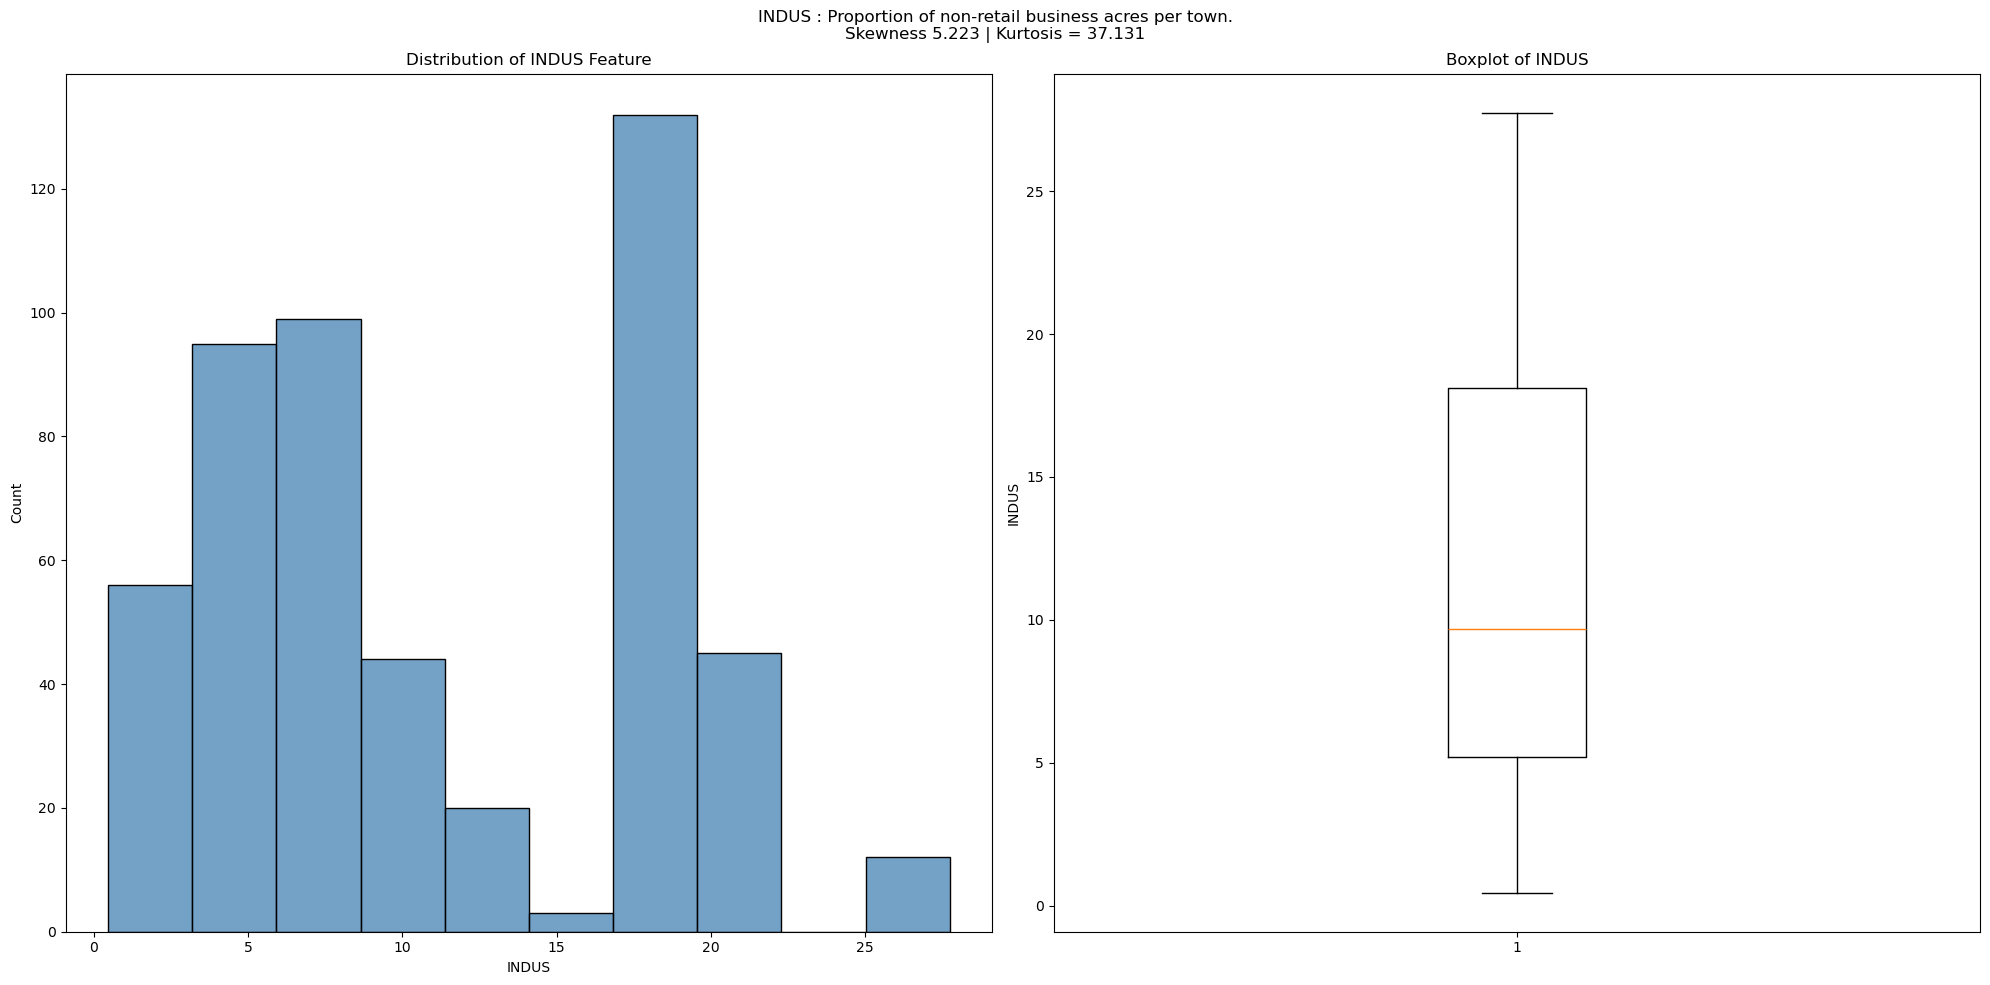

In [ ]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.histplot(x=df["INDUS"], color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of INDUS Feature")
axes[0].set_xlabel("INDUS")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["INDUS"], vert=True)
axes[1].set_title("Boxplot of INDUS")
axes[1].set_ylabel("INDUS")

plt.suptitle(f"INDUS : Proportion of non-retail business acres per town.\nSkewness {df['INDUS'].skew():.3f} | Kurtosis = {df['INDUS'].kurtosis():.3f}")
plt.tight_layout()
plt.show()

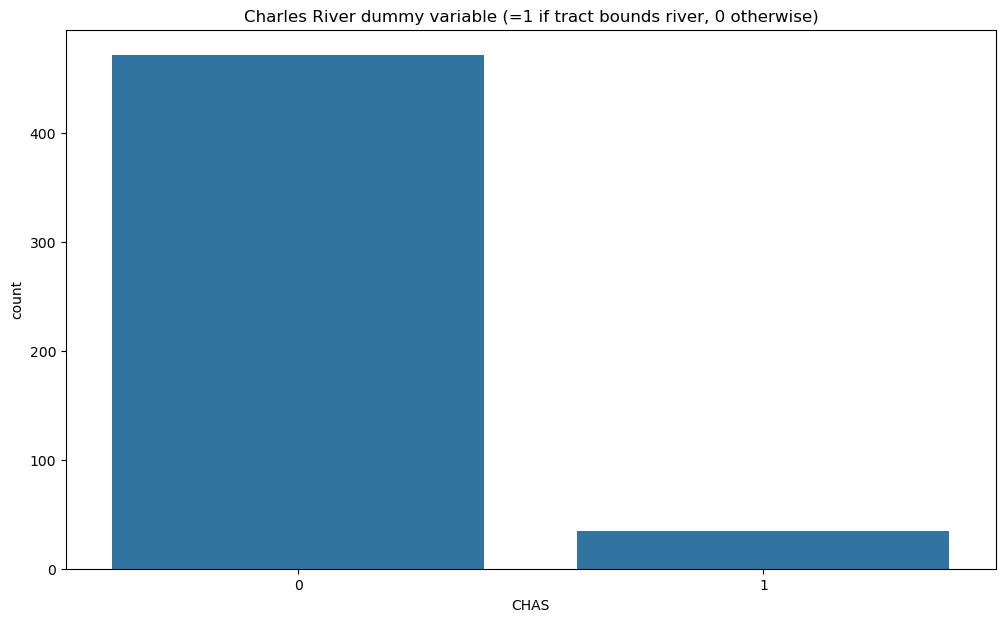

In [32]:
import seaborn as sns

plt.figure(figsize=(12,7))
sns.countplot(data=df, x="CHAS")
plt.title("Charles River dummy variable (=1 if tract bounds river, 0 otherwise)")
plt.show()


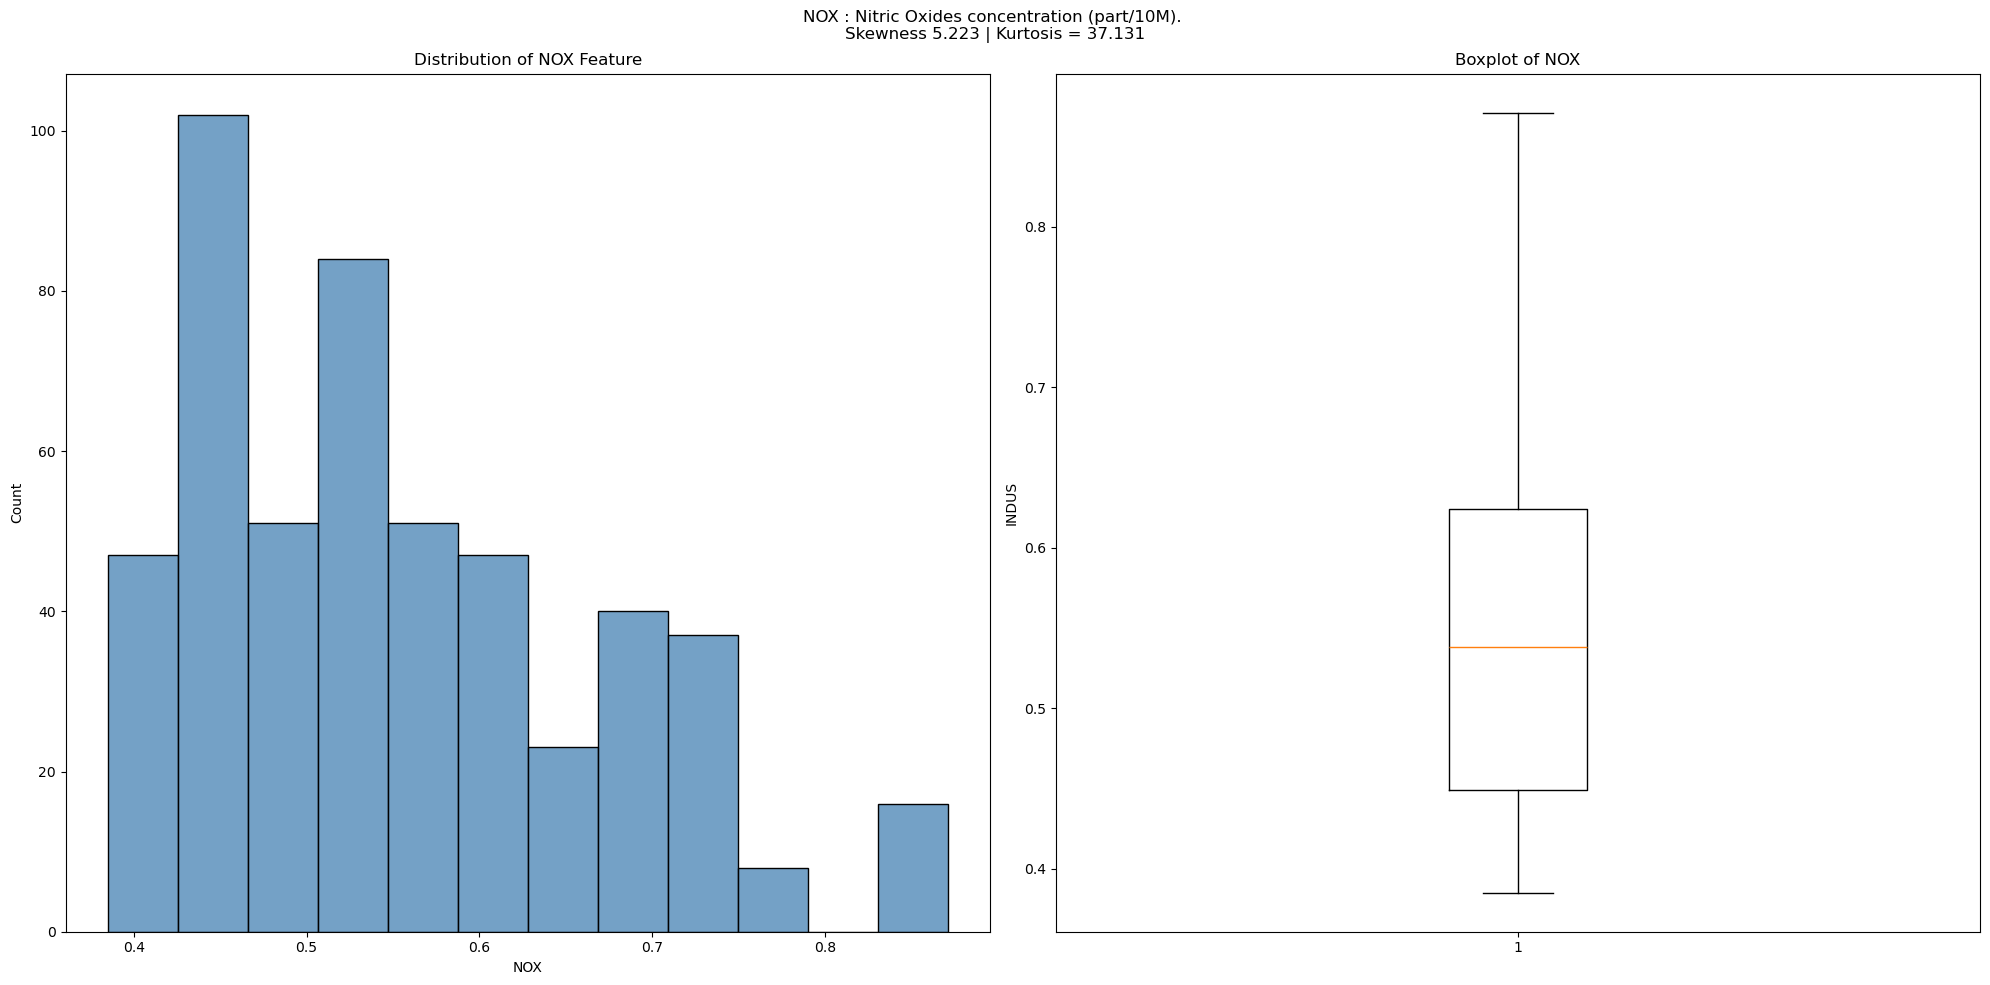

In [ ]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.histplot(x=df["NOX"], color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of NOX Feature")
axes[0].set_xlabel("NOX")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["NOX"], vert=True)
axes[1].set_title("Boxplot of NOX")
axes[1].set_ylabel("INDUS")

plt.suptitle(f"NOX : Nitric Oxides concentration (part/10M). \nSkewness {df['INDUS'].skew():.3f} | Kurtosis = {df['INDUS'].kurtosis():.3f}")
plt.tight_layout()
plt.show()

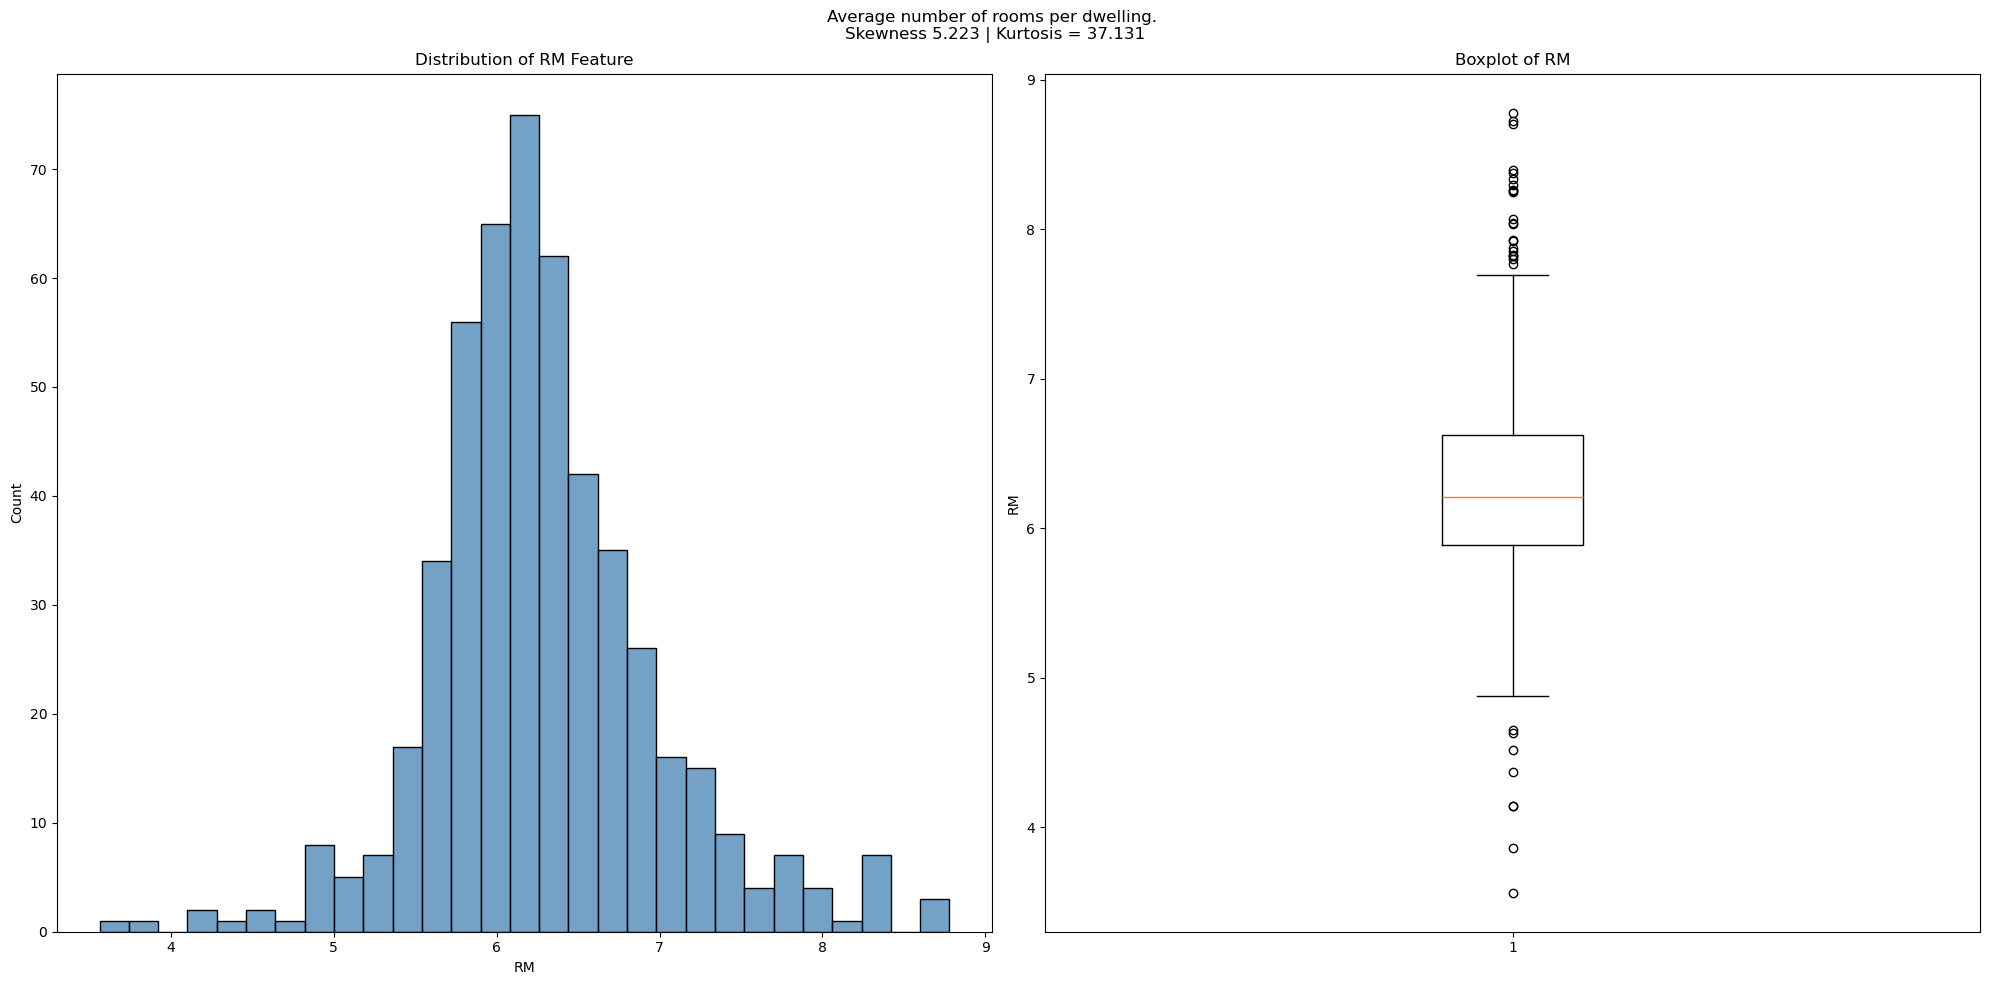

In [ ]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.histplot(x=df["RM"], color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of RM Feature")
axes[0].set_xlabel("RM")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["RM"], vert=True)
axes[1].set_title("Boxplot of RM")
axes[1].set_ylabel("RM")

plt.suptitle(f"Average number of rooms per dwelling. \nSkewness {df['RM'].skew():.3f} | Kurtosis = {df['RM'].kurtosis():.3f}")
plt.tight_layout()
plt.show()

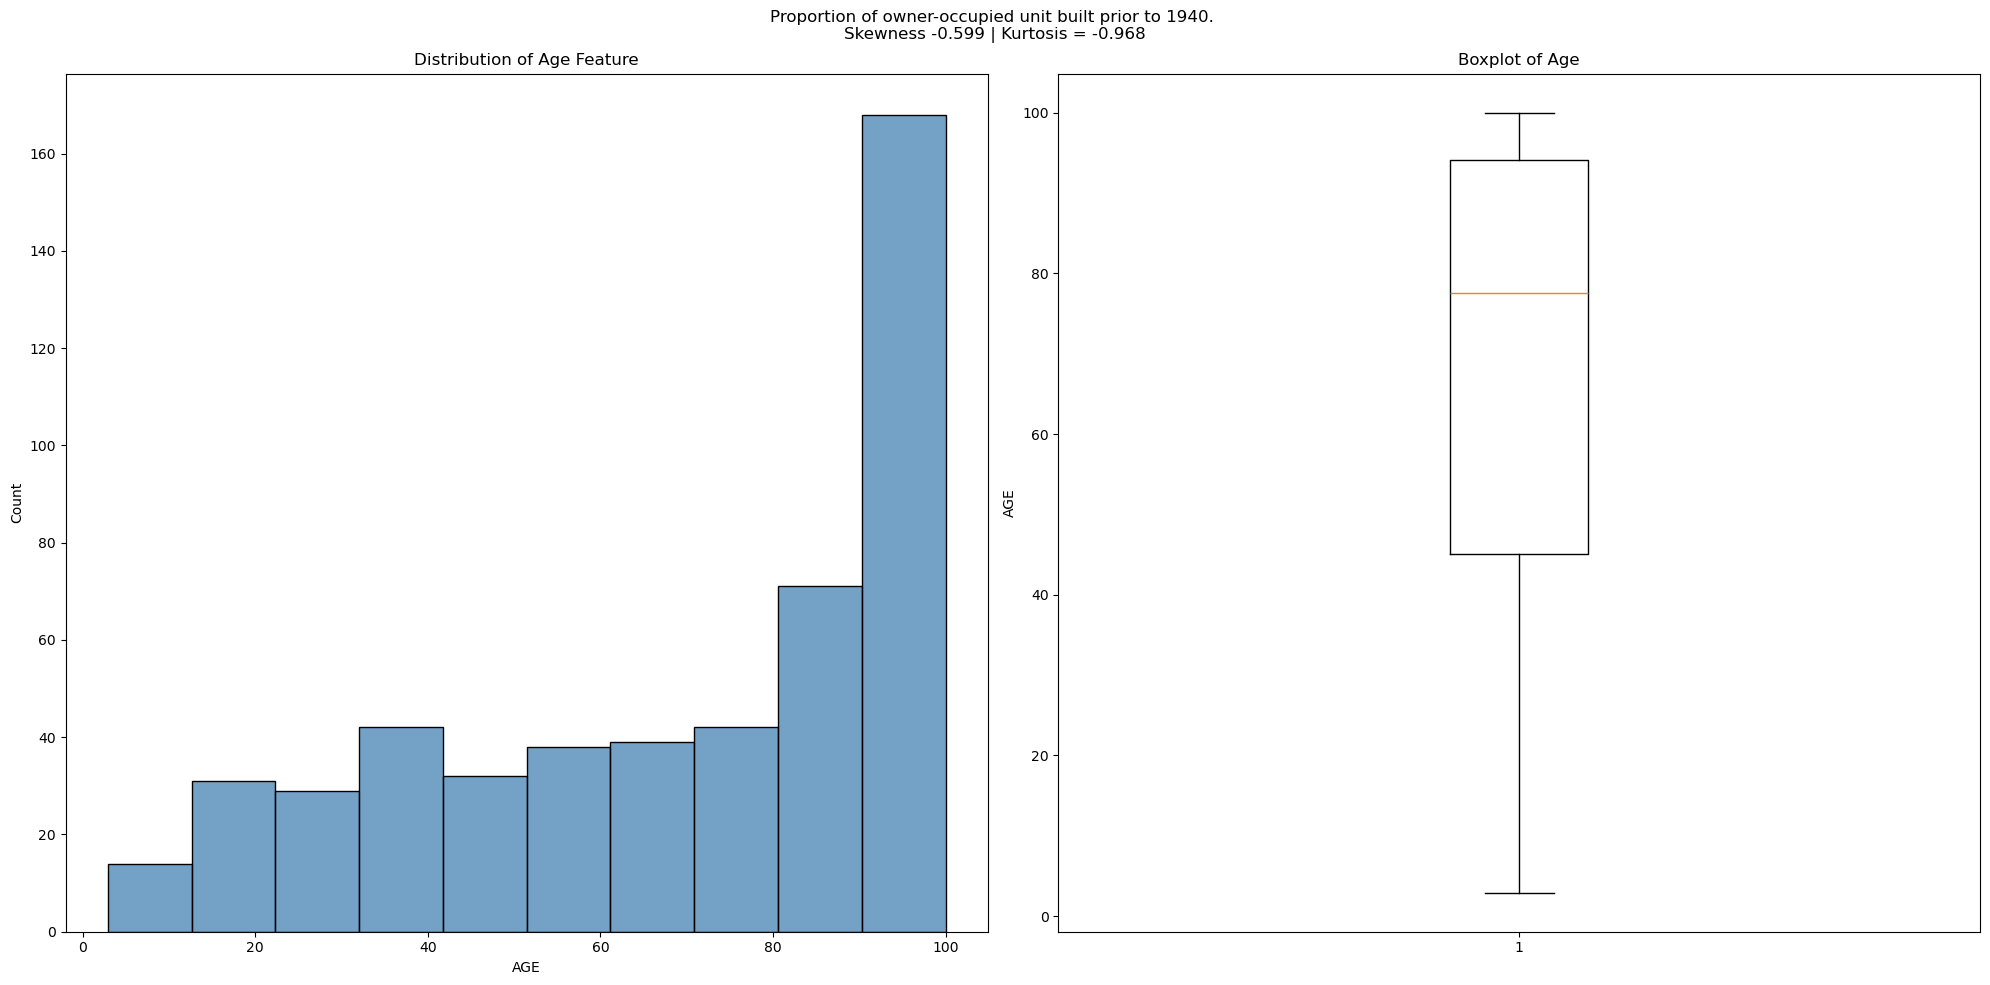

In [42]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.histplot(x=df["AGE"], color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of Age Feature")
axes[0].set_xlabel("AGE")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["AGE"], vert=True)
axes[1].set_title("Boxplot of Age")
axes[1].set_ylabel("AGE")

plt.suptitle(f"Proportion of owner-occupied unit built prior to 1940. \nSkewness {df['AGE'].skew():.3f} | Kurtosis = {df['AGE'].kurtosis():.3f}")
plt.tight_layout()
plt.show()

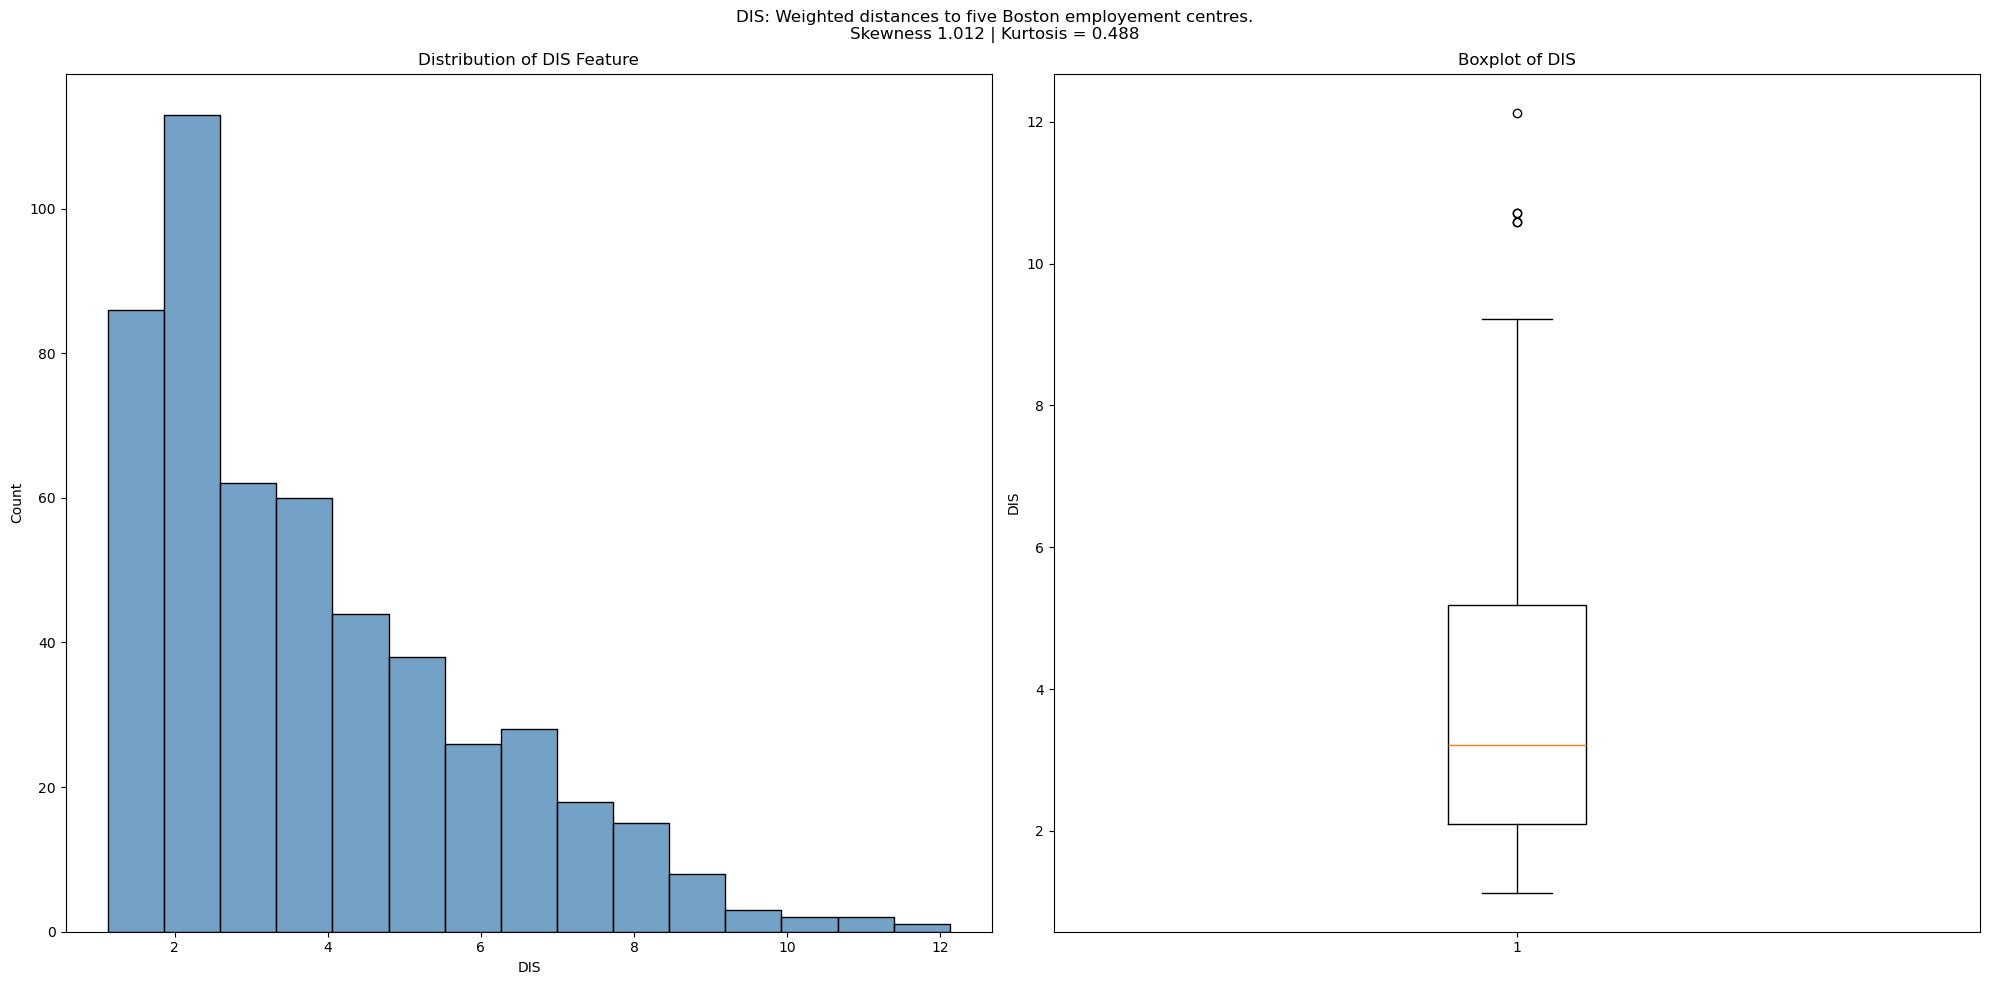

In [43]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.histplot(x=df["DIS"], color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of DIS Feature")
axes[0].set_xlabel("DIS")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["DIS"], vert=True)
axes[1].set_title("Boxplot of DIS")
axes[1].set_ylabel("DIS")

plt.suptitle(f"DIS: Weighted distances to five Boston employement centres.\nSkewness {df['DIS'].skew():.3f} | Kurtosis = {df['DIS'].kurtosis():.3f}")
plt.tight_layout()
plt.show()

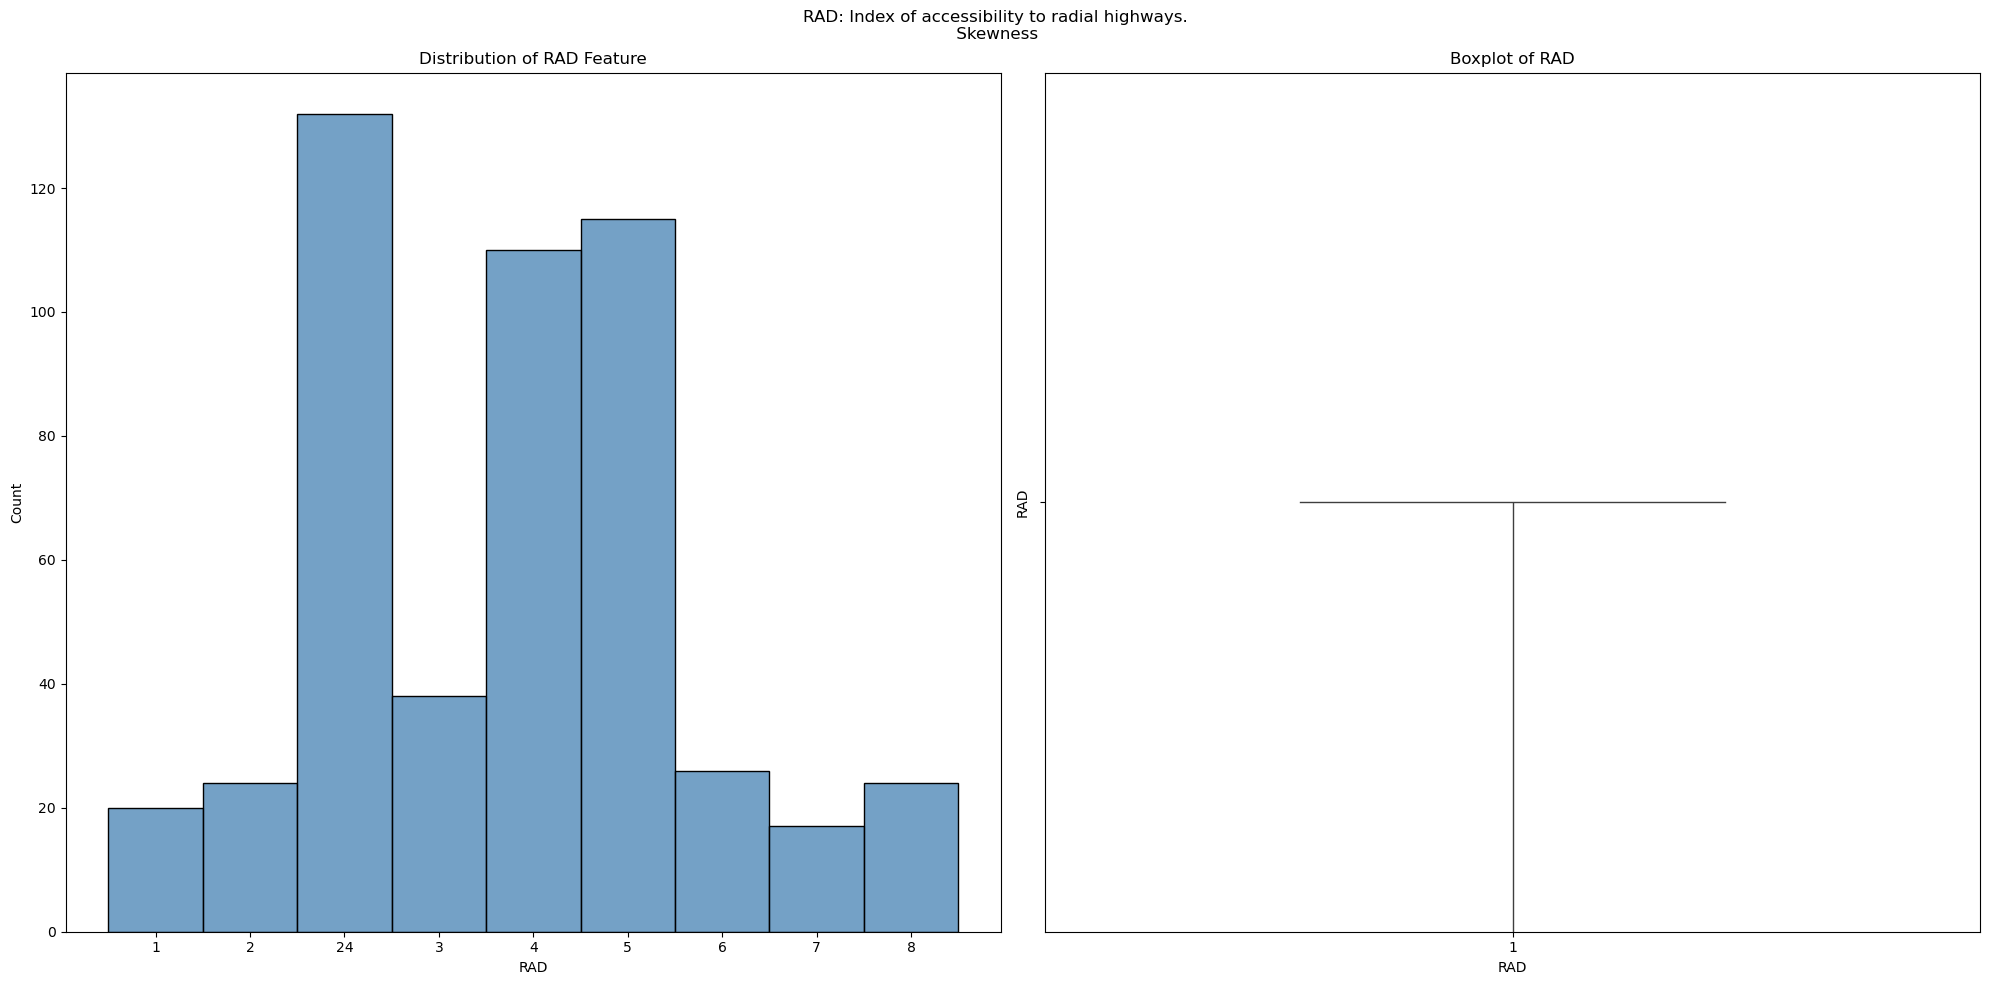

In [45]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.histplot(x=df["RAD"], color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of RAD Feature")
axes[0].set_xlabel("RAD")
axes[0].set_ylabel("Count")

sns.boxplot(x=df["RAD"], vert=True)
axes[1].set_title("Boxplot of RAD")
axes[1].set_ylabel("RAD")

plt.suptitle(f"RAD: Index of accessibility to radial highways.\n Skewness")
plt.tight_layout()
plt.show()

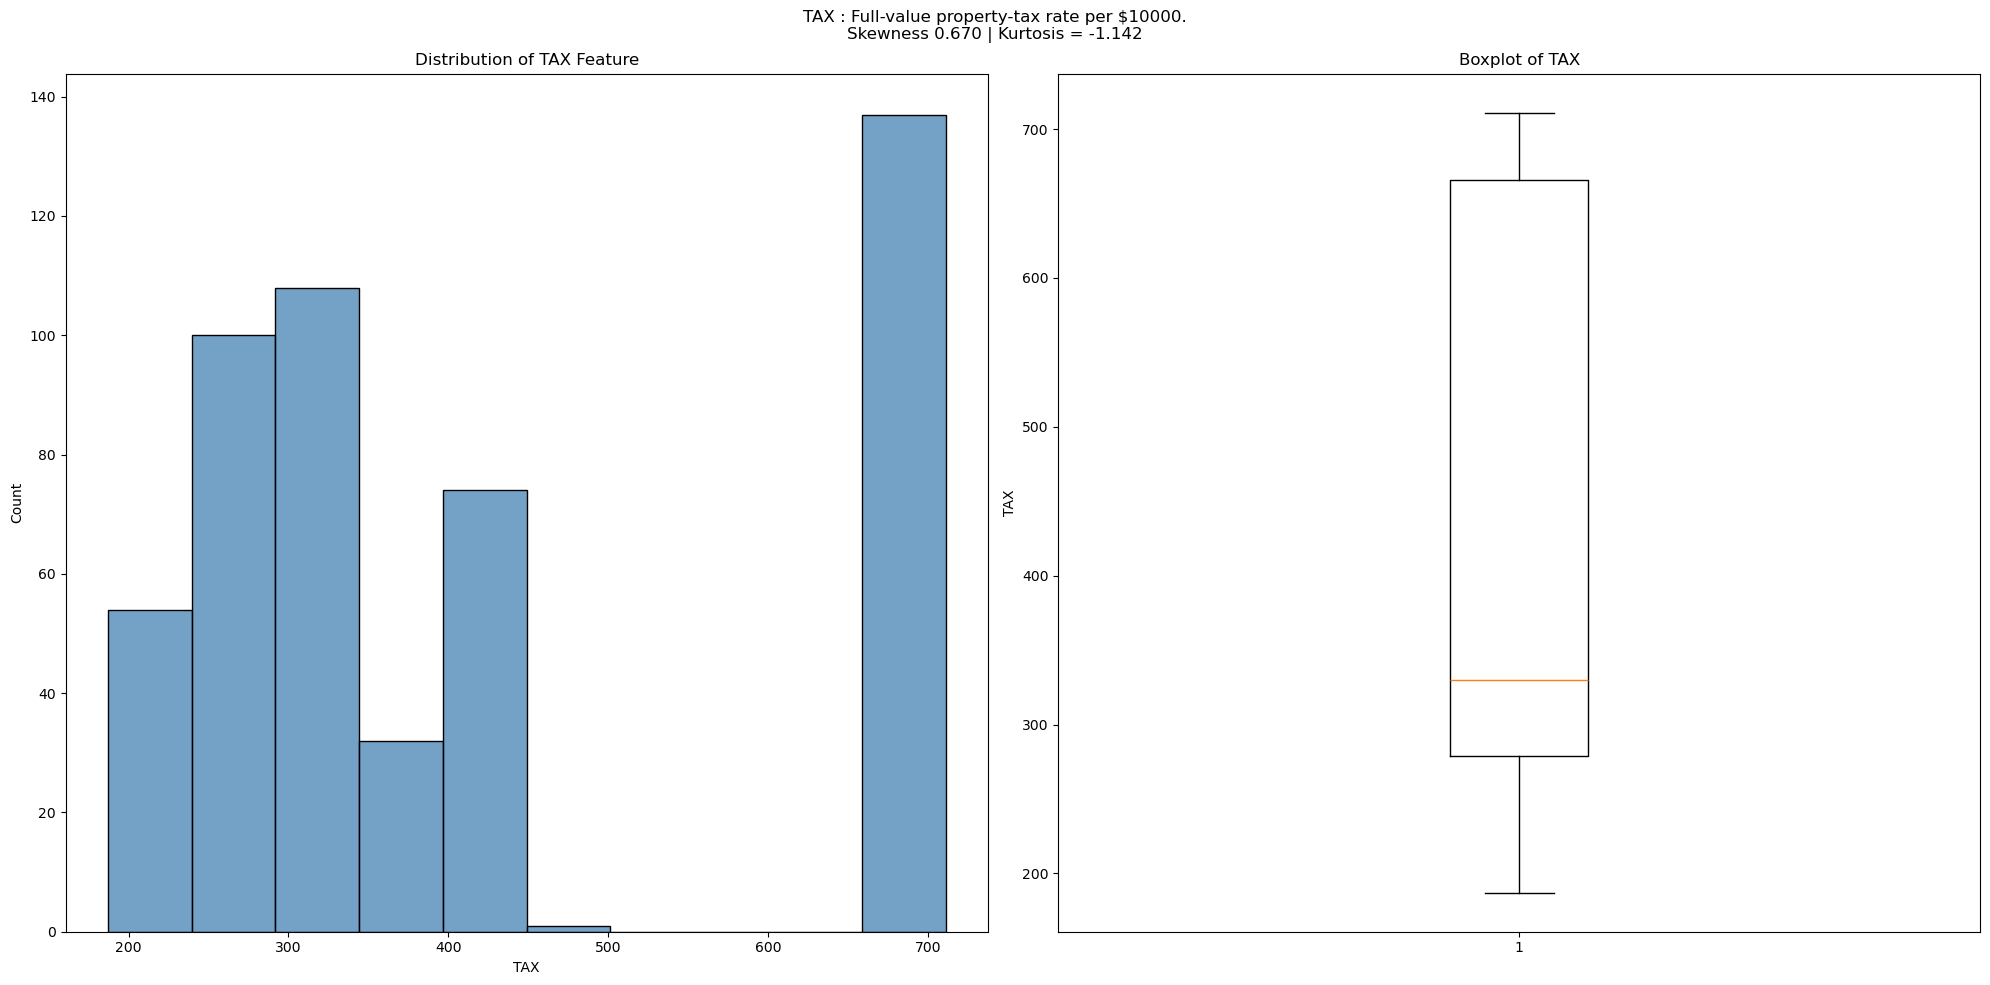

In [46]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.histplot(x=df["TAX"], color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of TAX Feature")
axes[0].set_xlabel("TAX")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["TAX"], vert=True)
axes[1].set_title("Boxplot of TAX")
axes[1].set_ylabel("TAX")

plt.suptitle(f"TAX : Full-value property-tax rate per $10000.\nSkewness {df['TAX'].skew():.3f} | Kurtosis = {df['TAX'].kurtosis():.3f}")
plt.tight_layout()
plt.show()

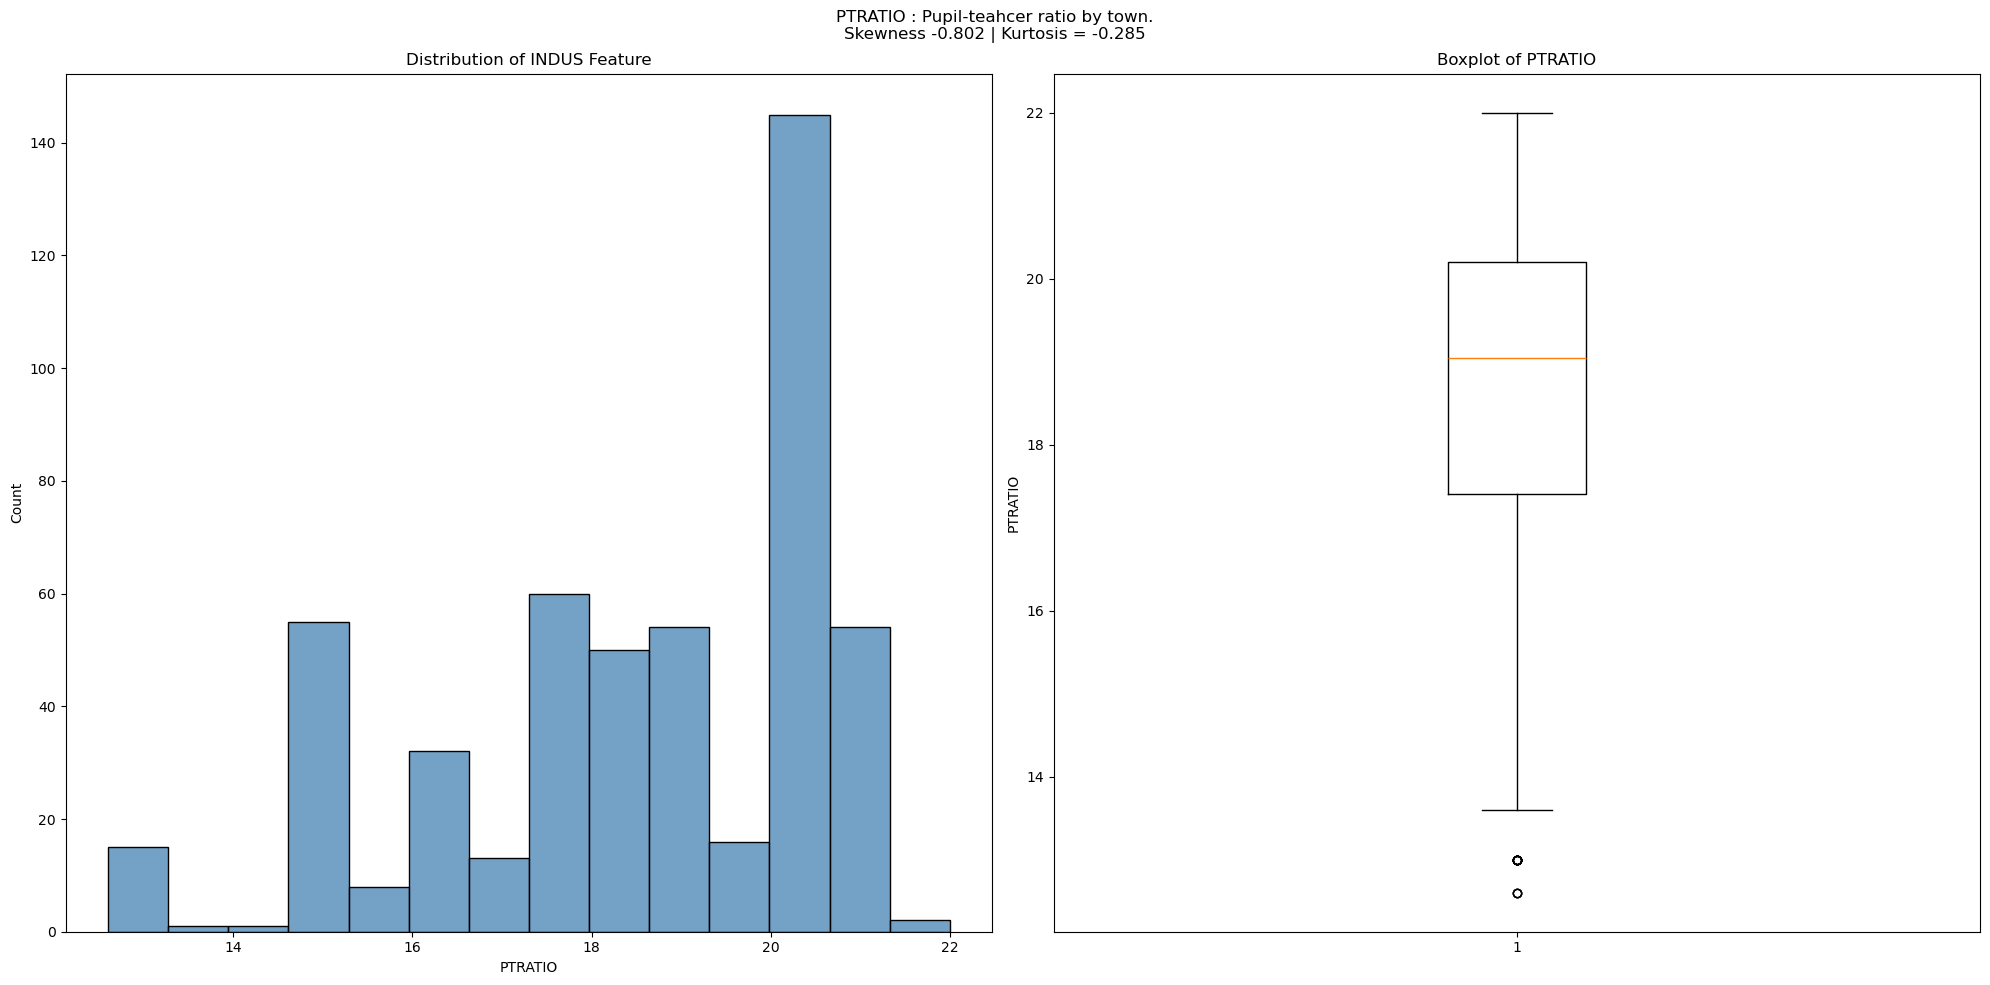

In [48]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.histplot(x=df["PTRATIO"], color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of INDUS Feature")
axes[0].set_xlabel("PTRATIO")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["PTRATIO"], vert=True)
axes[1].set_title("Boxplot of PTRATIO")
axes[1].set_ylabel("PTRATIO")

plt.suptitle(f"PTRATIO : Pupil-teahcer ratio by town.\nSkewness {df['PTRATIO'].skew():.3f} | Kurtosis = {df['PTRATIO'].kurtosis():.3f}")
plt.tight_layout()
plt.show()

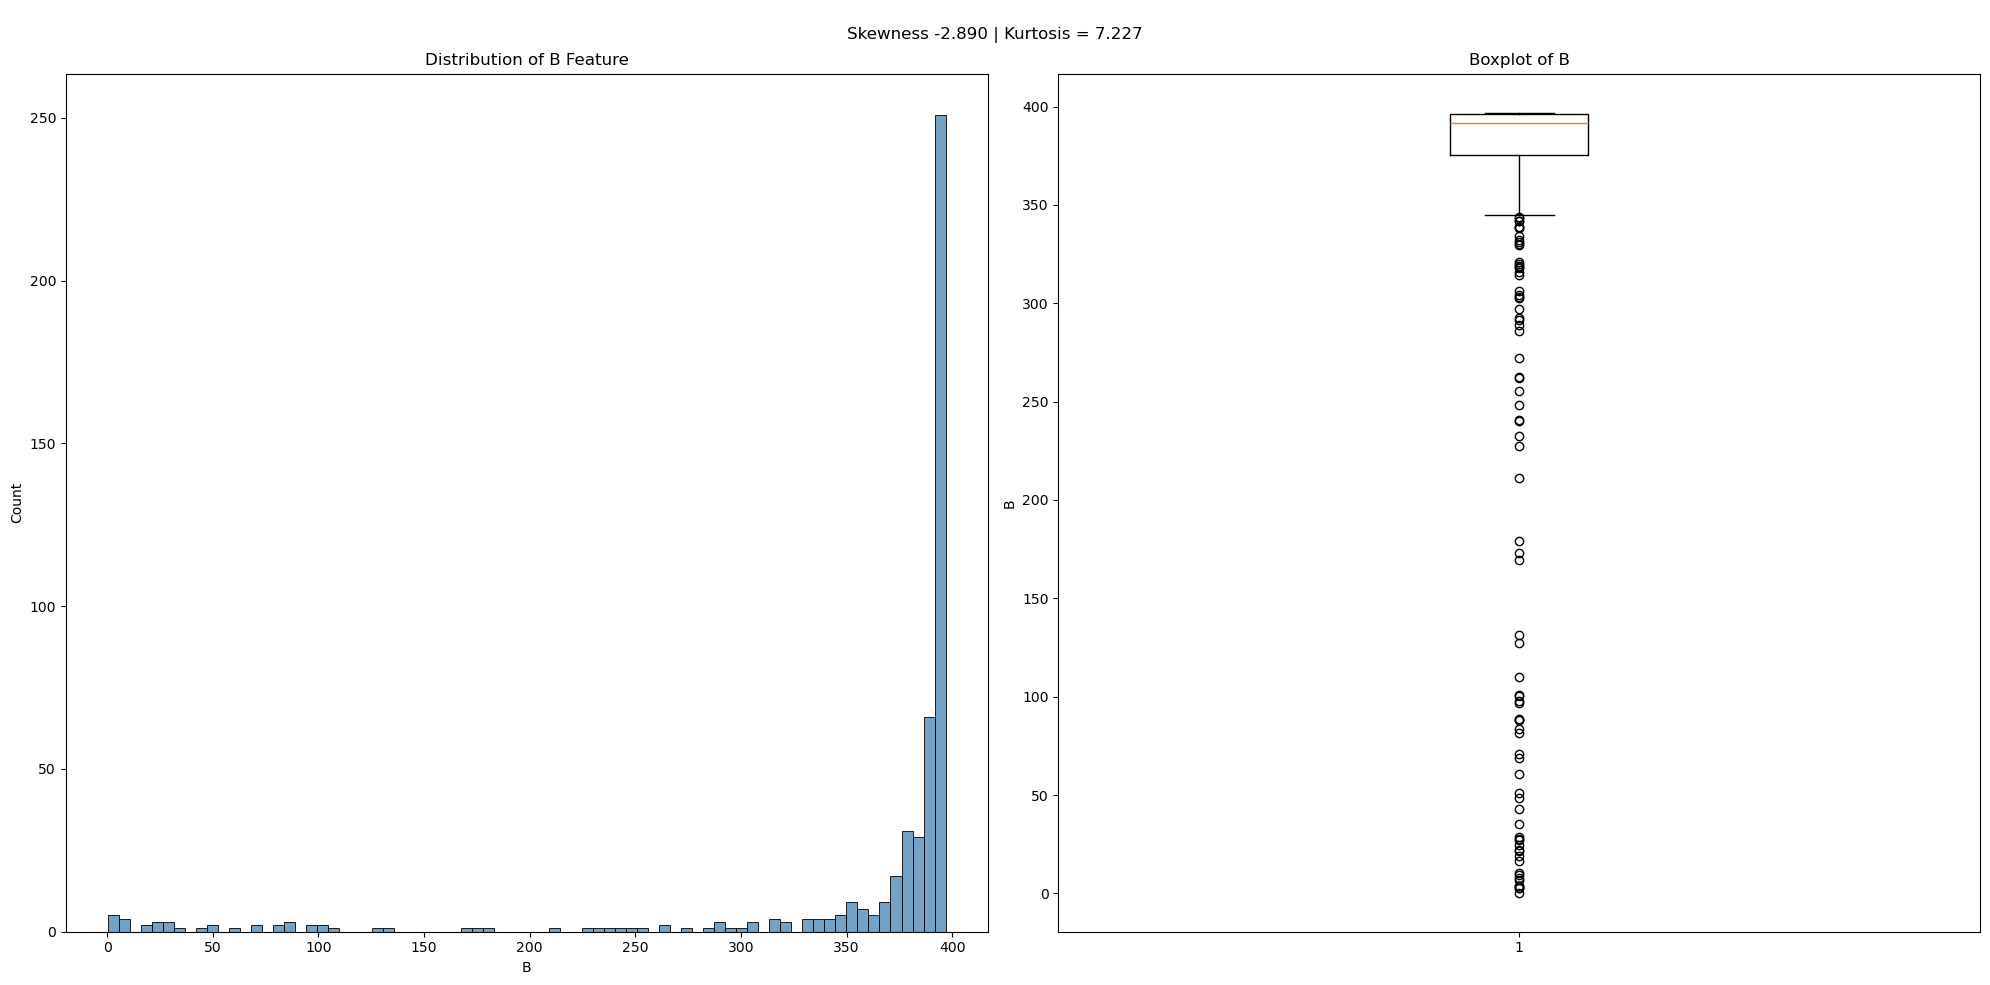

In [49]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.histplot(x=df["B"], color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of B Feature")
axes[0].set_xlabel("B")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["B"], vert=True)
axes[1].set_title("Boxplot of B")
axes[1].set_ylabel("B")

plt.suptitle(f"\nSkewness {df['B'].skew():.3f} | Kurtosis = {df['B'].kurtosis():.3f}")
plt.tight_layout()
plt.show()

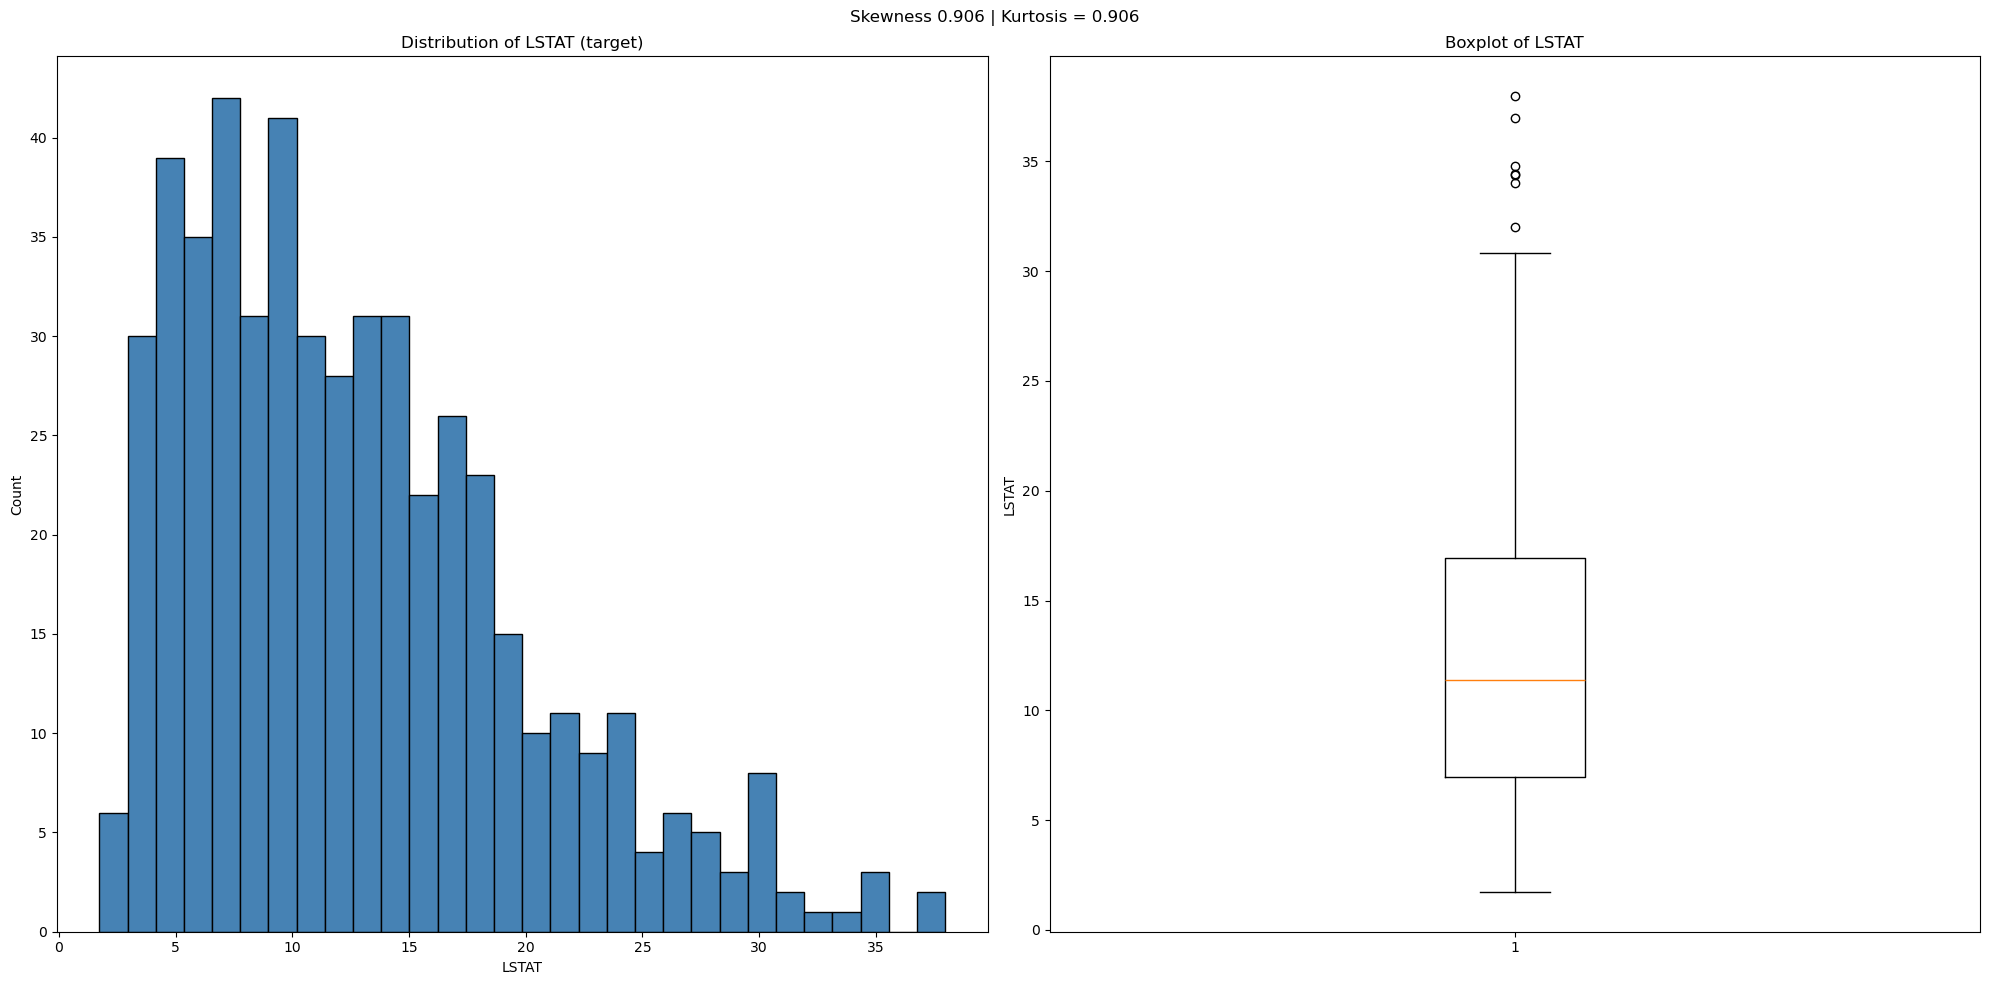

In [51]:
fig, axes = plt.subplots(1,2, figsize=(20,10))

axes[0].hist(df["LSTAT"], bins=30, edgecolor="black", color="steelblue")
axes[0].set_title("Distribution of LSTAT (target)")
axes[0].set_xlabel("LSTAT")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["LSTAT"], vert=True)
axes[1].set_title("Boxplot of LSTAT")
axes[1].set_ylabel("LSTAT")

plt.suptitle(f"Skewness {df["LSTAT"].skew():.3f} | Kurtosis = {df['LSTAT'].skew():.3f}")
plt.tight_layout()
plt.show()


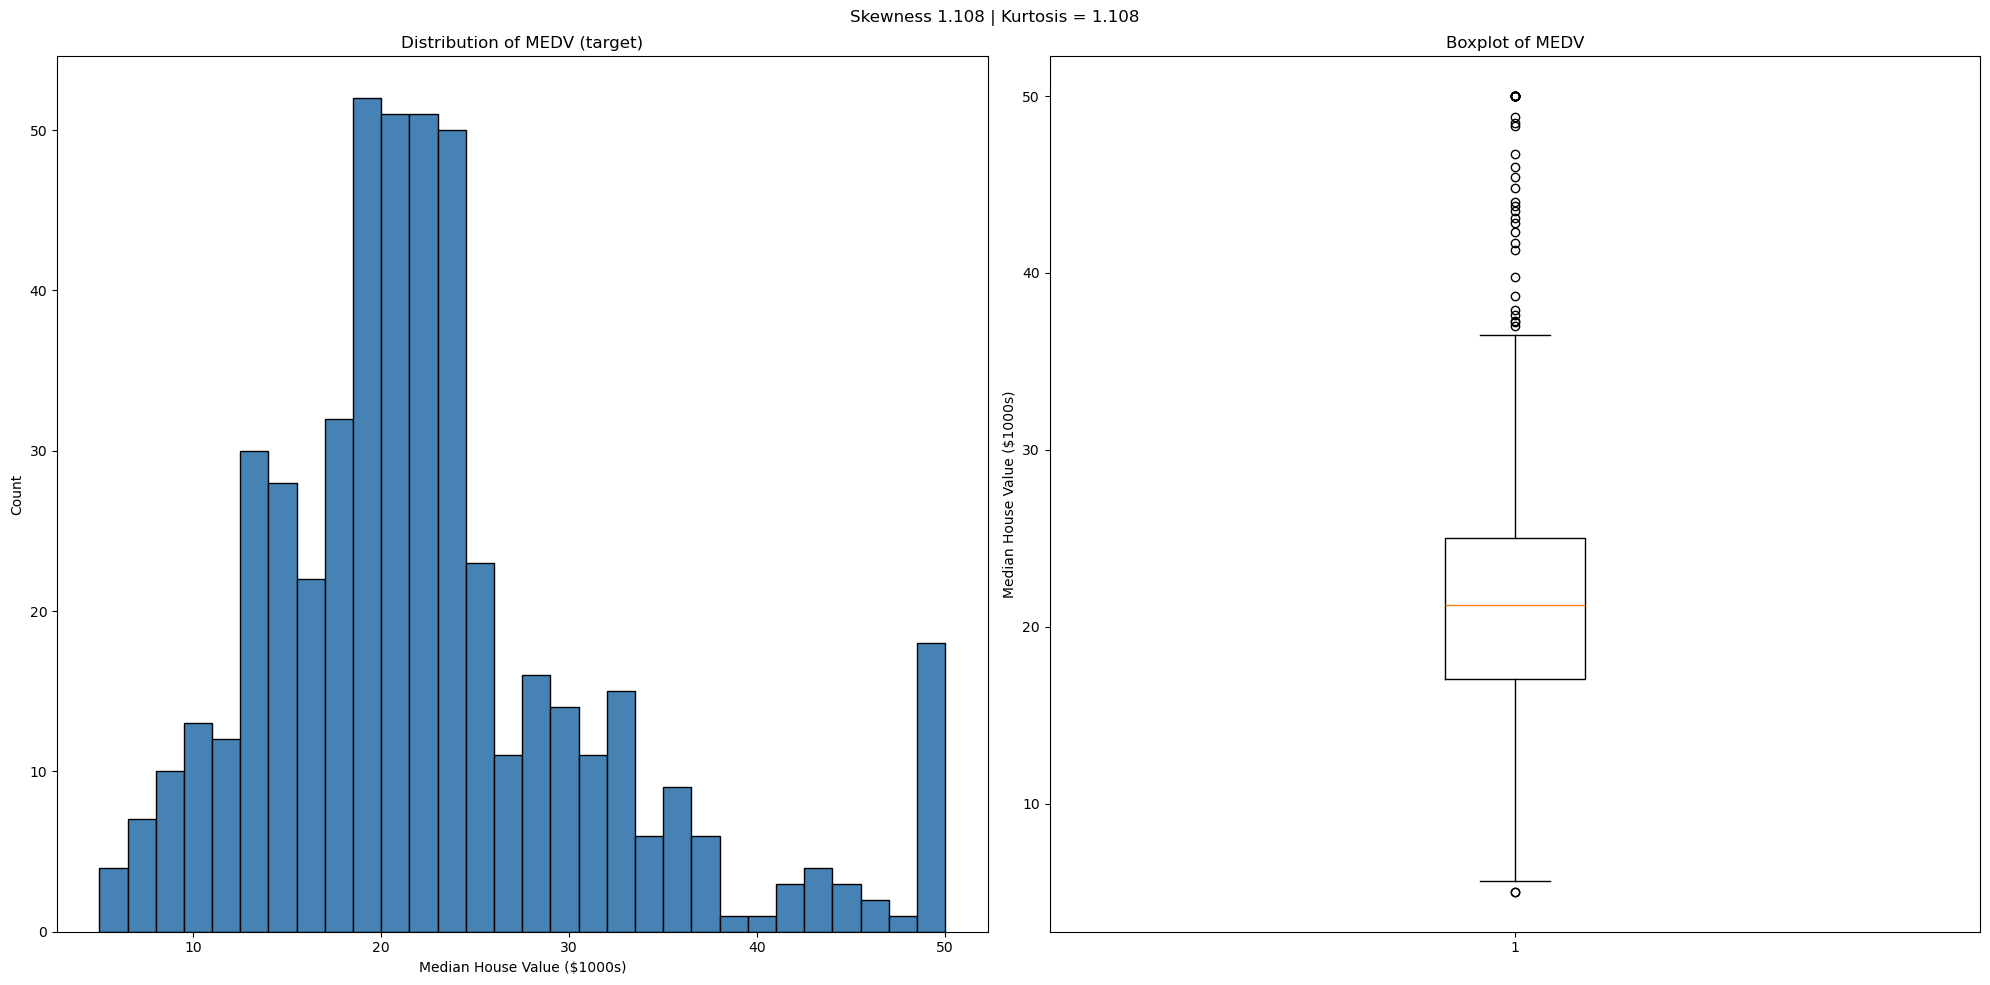

In [52]:
fig, axes = plt.subplots(1,2, figsize=(20,10))

axes[0].hist(df["MEDV"], bins=30, edgecolor="black", color="steelblue")
axes[0].set_title("Distribution of MEDV (target)")
axes[0].set_xlabel("Median House Value ($1000s)")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["MEDV"], vert=True)
axes[1].set_title("Boxplot of MEDV")
axes[1].set_ylabel("Median House Value ($1000s)")

plt.suptitle(f"Skewness {df["MEDV"].skew():.3f} | Kurtosis = {df['MEDV'].skew():.3f}")
plt.tight_layout()
plt.show()


# Preprocessing

In [61]:
x = df[df.columns.difference(['MEDV'])].astype({
    "CHAS": float,
    "RAD": float
})
y = df["MEDV"]

In [62]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.8, random_state=0)

print(f"x_train shape = {x_train.shape}")
print(f"x_test shape = {x_test.shape}")
print(f"y_train shape = {y_train.shape}")
print(f"y_test shape = {y_test.shape}")

x_train shape = (404, 13)
x_test shape = (102, 13)
y_train shape = (404,)
y_test shape = (102,)


In [63]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train, y_train)

LinearRegression()

In [64]:
y_pred = regressor.predict(x_test)

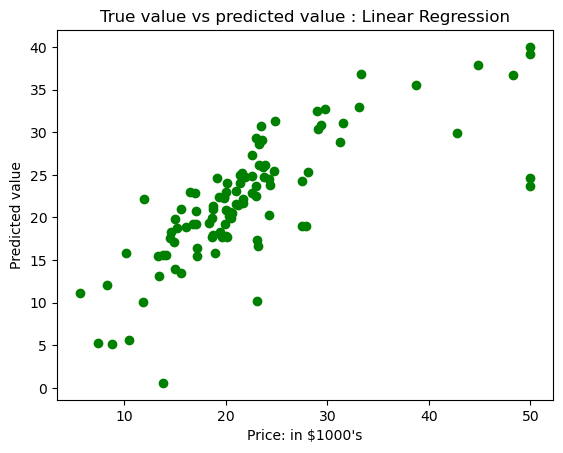

In [65]:
plt.scatter(y_test, y_pred, c = 'green')
plt.xlabel("Price: in $1000's")
plt.ylabel("Predicted value")
plt.title("True value vs predicted value : Linear Regression")
plt.show()

In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test,y_pred)
print("Mean Square Error : ", mse)
print("Mean Absolute Error : ", mae)

Mean Square Error :  33.44897999767657
Mean Absolute Error :  3.8429092204445094
